<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/skill_morph_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [5]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [9]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nLabels:\n", df['attack_detected'].value_counts().sort_index())
print("\nClass mapping: 0 = No Attack (Normal), 1 = Attack Detected")

Missing values per column:
 encryption_used    1966
dtype: int64

Labels:
 attack_detected
0    5273
1    4264
Name: count, dtype: int64

Class mapping: 0 = No Attack (Normal), 1 = Attack Detected


In [10]:
# Drop structurally irrelevant identifier/categorical strings as requested by the workflow
df.drop(columns=['session_id', 'protocol_type', 'encryption_used', 'browser_type'], inplace=True, errors='ignore')

# Handle missing values explicitly using feature medians
df.fillna(df.median(numeric_only=True), inplace=True)

# Split features and label
X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

# Scale features and execute 80/20 train-test split
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 7629 | Test: 1908


/tmp/ipykernel_1890/2379611188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette='viridis', edgecolor='black')
/tmp/ipykernel_1890/2379611188.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, ax=axes[1], palette='magma', edgecolor='black')


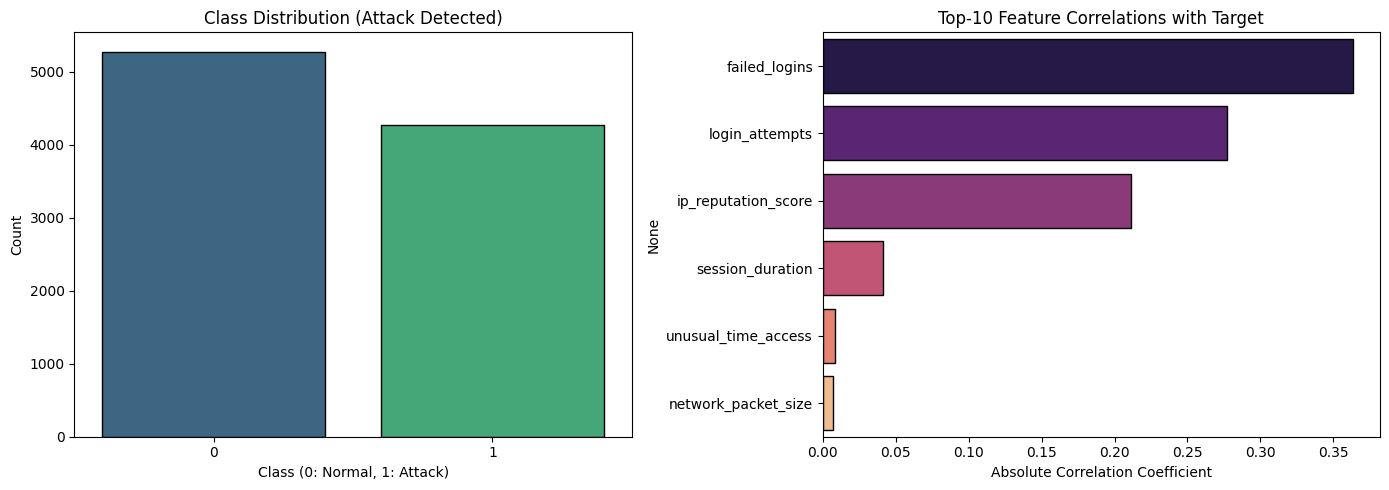

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart of Class Distribution
sns.countplot(x=y, ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('Class Distribution (Attack Detected)')
axes[0].set_xlabel('Class (0: Normal, 1: Attack)')
axes[0].set_ylabel('Count')

# 2. Top-10 Feature Correlations with the target variable
correlations = df.corr()['attack_detected'].drop('attack_detected').abs().sort_values(ascending=False).head(10)
sns.barplot(x=correlations.values, y=correlations.index, ax=axes[1], palette='magma', edgecolor='black')
axes[1].set_title('Top-10 Feature Correlations with Target')
axes[1].set_xlabel('Absolute Correlation Coefficient')

plt.tight_layout()
plt.show()

In [13]:
# Initialize baseline models with requested hyperparameters
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg': LogisticRegression(max_iter=1000, random_state=20)
}

predictions = {}
baseline_results = []

# Train and collect performance indicators
for name, model in models.items():
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    predictions[name] = yp

    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'),
        'F1-Score': f1_score(y_test, yp, average='weighted')
    })

baseline_df = pd.DataFrame(baseline_results).set_index('Model')
print("Baseline Models Performance Summary:")
print(baseline_df.round(4))

Baseline Models Performance Summary:
               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree    0.7956     0.7979  0.7956    0.7962
KNN (k=5)        0.8422     0.8458  0.8422    0.8401
Logistic Reg     0.7348     0.7335  0.7348    0.7332


Decision Tree Complexity Evaluation Table:
           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8852     0.9046  0.8852    0.8818
5            0.8873     0.9061  0.8873    0.8841
10           0.8768     0.8899  0.8768    0.8739
15           0.8585     0.8637  0.8585    0.8563
20           0.8407     0.8420  0.8407    0.8392
25           0.8181     0.8177  0.8181    0.8178
30           0.8050     0.8051  0.8050    0.8051
35           0.8014     0.8024  0.8014    0.8017
40           0.7987     0.8007  0.7987    0.7993
None         0.7956     0.7979  0.7956    0.7962


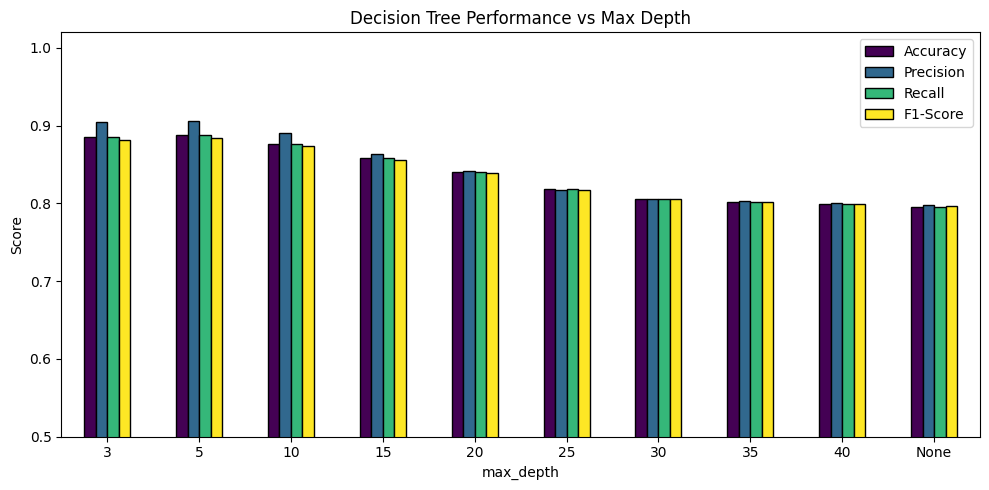

In [17]:
dt_results = []

# Tune across max_depth options: [3, 5, 10, 15, 20,25,30,35,40, None]
for d in [3, 5, 10, 15, 20,25,30,35,40, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({
        'max_depth': str(d) if d is not None else 'None',
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'),
        'F1-Score': f1_score(y_test, yp, average='weighted')
    })

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print("Decision Tree Complexity Evaluation Table:")
print(dt_df.round(4))

# Plot structural depth impact comparisons
dt_df.plot(kind='bar', figsize=(10, 5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree Performance vs Max Depth')
plt.ylabel('Score')
plt.ylim(0.5, 1.02)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
target_names = ['Normal (0)', 'Attack (1)']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
              precision    recall  f1-score   support

  Normal (0)     0.8351    0.7948    0.8145      1077
  Attack (1)     0.7497    0.7966    0.7725       831

    accuracy                         0.7956      1908
   macro avg     0.7924    0.7957    0.7935      1908
weighted avg     0.7979    0.7956    0.7962      1908


KNN (k=5)
              precision    recall  f1-score   support

  Normal (0)     0.8223    0.9192    0.8680      1077
  Attack (1)     0.8764    0.7425    0.8039       831

    accuracy                         0.8422      1908
   macro avg     0.8493    0.8308    0.8360      1908
weighted avg     0.8458    0.8422    0.8401      1908


Logistic Reg
              precision    recall  f1-score   support

  Normal (0)     0.7493    0.7967    0.7723      1077
  Attack (1)     0.7130    0.6546    0.6826       831

    accuracy                         0.7348      1908
   macro avg     0.7312    0.7256    0.7274      1908
weighted avg     0.7335    0.7348 

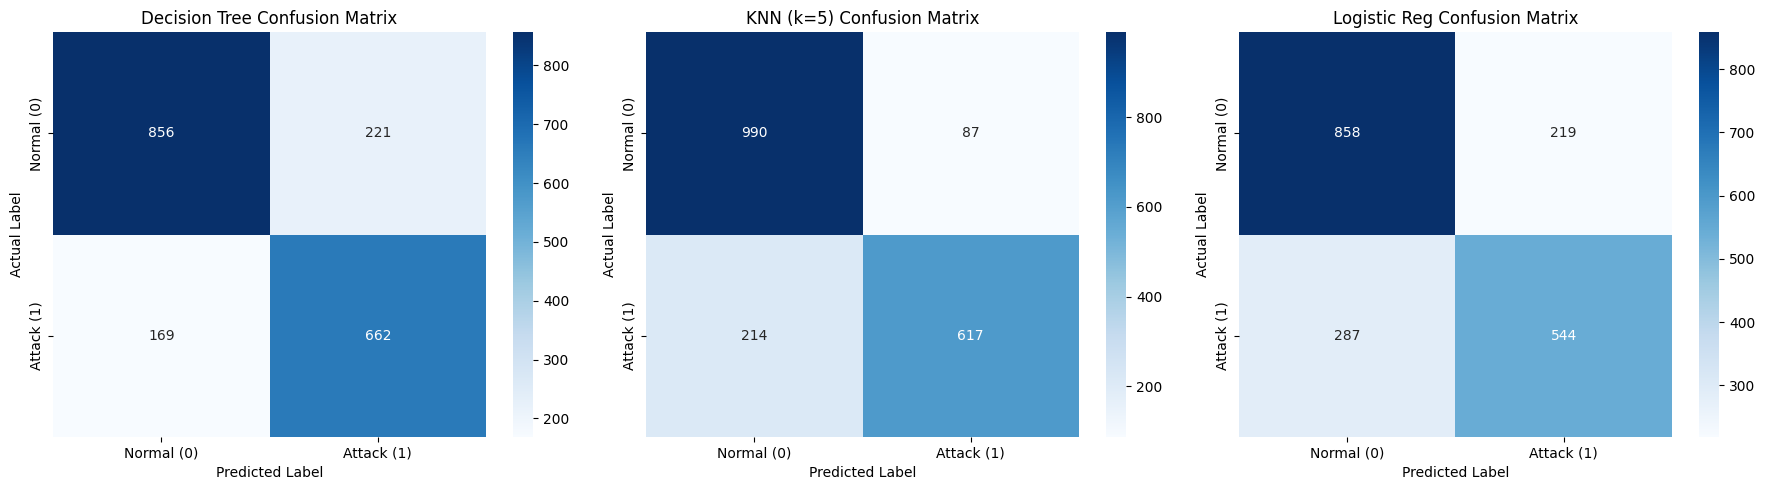

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, yp) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

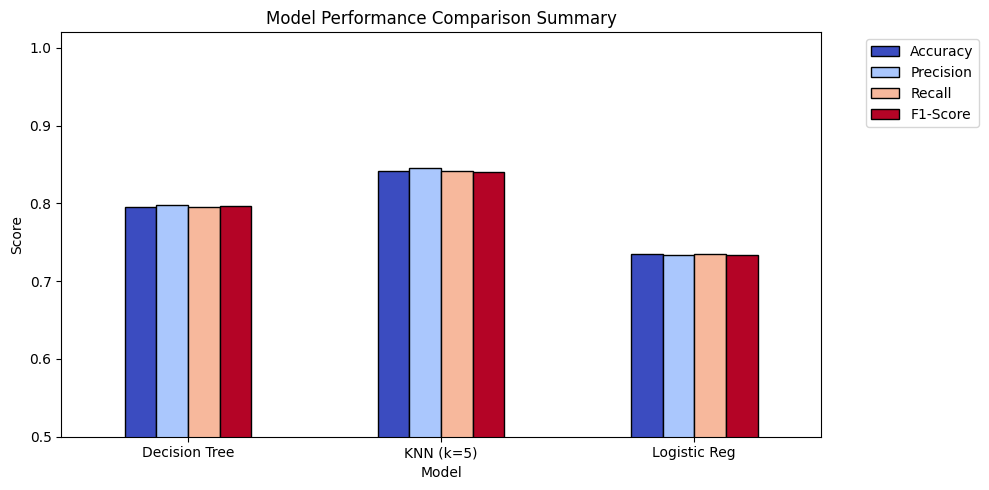

In [20]:
# Generate a unified comparative visual chart representing baseline models
baseline_df.plot(kind='bar', figsize=(10, 5), colormap='coolwarm', edgecolor='black')
plt.title('Model Performance Comparison Summary')
plt.ylabel('Score')
plt.ylim(0.5, 1.02)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()